# Content-Based Filtering: Rekomendasi Kafe di Yogyakarta

**Mata Kuliah:** Sistem Temu Balik Informasi  
**Tugas:** Implementasi CBF pada dataset projek final  
**Oleh:** Sinta Siti Nuriah & Gilbert Fandiliam Mooy 

---

## Latar Belakang

**Content-Based Filtering (CBF)** adalah metode sistem rekomendasi yang merekomendasikan item berdasarkan kemiripan konten/fitur item itu sendiri, bukan dari perilaku pengguna lain. Dalam konteks ini:

- **Item** = Kafe
- **Konten/Fitur** = Teks ulasan pengunjung yang diagregasi per kafe
- **User Profile** = Gabungan representasi vektor kafe-kafe yang pernah dikunjungi/disukai user
- **Output** = Rekomendasi kafe lain yang paling mirip secara konten

### Alur Kerja CBF

```
[1] Kumpulkan Fitur Item
        ↓
[2] Bangun Item Profile (TF-IDF Vector per Kafe)
        ↓
[3] Bangun User Profile (Rata-rata vektor kafe yang disukai)
        ↓
[4] Hitung Cosine Similarity
        ↓
[5] Ranking & Rekomendasi Top-N
```

### Dataset
Data ulasan Google Maps dari **84 kafe** di Yogyakarta dengan total **±32.000 ulasan**.

---
## 1. Import Library

In [1]:
# Library standar Python
import os                      # Operasi path dan file sistem
import glob                    # Pencarian file dengan pattern wildcard
import re                      # Regular expression untuk preprocessing teks
import warnings                # Menyembunyikan warning yang tidak perlu
warnings.filterwarnings('ignore')

# Library untuk manipulasi data tabular
import numpy as np             # Operasi numerik dan array
import pandas as pd            # Manipulasi DataFrame
import nltk

# Library visualisasi
import matplotlib.pyplot as plt          # Plot dasar
import matplotlib.ticker as mticker      # Formatter angka pada sumbu
import seaborn as sns                    # Visualisasi statistik berbasis matplotlib

# Library NLP / Feature Extraction dari scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer   # TF-IDF vectorizer
from sklearn.metrics.pairwise import cosine_similarity         # Cosine similarity
from sklearn.preprocessing import MinMaxScaler                 # Normalisasi fitur numerik
from nltk.corpus import stopwords


# Download data stopword (hanya perlu sekali)
nltk.download('stopwords')

# Konfigurasi tampilan pandas agar tidak terpotong
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', 10)

# Konfigurasi style visualisasi
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Semua library berhasil diimport.')

Semua library berhasil diimport.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sinta\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
## 2. Load Data

Seluruh file CSV dipisahkan oleh delimiter `~` (bukan koma). Setiap file mewakili satu kafe dengan kolom utama: `nama_tempat`, `rating`, `teks_ulasan`.

In [20]:
# Cari semua file CSV dalam folder project
csv_files = glob.glob('./csv/*.csv')

# Buat list untuk menampung DataFrame tiap file
dfs = []
error_files = []

for filepath in csv_files:
    try:
        # Baca CSV dengan delimiter '~', encoding utf-8-sig (menangani BOM karakter)
        # on_bad_lines='skip' agar baris yang rusak tidak menghentikan proses
        df = pd.read_csv(filepath, sep='~', encoding='utf-8-sig', on_bad_lines='skip')
        dfs.append(df)
    except Exception as e:
        error_files.append((os.path.basename(filepath), str(e)))

# Gabungkan semua DataFrame menjadi satu
raw_df = pd.concat(dfs, ignore_index=True)

print(f'Jumlah file berhasil dibaca : {len(dfs)}')
print(f'Jumlah file gagal dibaca    : {len(error_files)}')
print(f'Total baris (ulasan)        : {len(raw_df):,}')
print(f'Jumlah kolom                : {raw_df.shape[1]}')

Jumlah file berhasil dibaca : 84
Jumlah file gagal dibaca    : 0
Total baris (ulasan)        : 32,804
Jumlah kolom                : 41


In [37]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32804 entries, 0 to 32803
Data columns (total 41 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   no_urut                        32804 non-null  int64  
 1   id_review                      32804 non-null  object 
 2   nama_tempat                    32804 non-null  object 
 3   nama_reviewer                  32804 non-null  object 
 4   status_reviewer                32209 non-null  object 
 5   rating                         31602 non-null  float64
 6   tanggal                        31602 non-null  object 
 7   teks_ulasan                    26215 non-null  object 
 8   jenis_makanan                  4290 non-null   object 
 9   jenis_pesanan                  3750 non-null   object 
 10  kesesuaian_untuk_anakanak      67 non-null     object 
 11  layanan                        10651 non-null  object 
 12  makanan                        8730 non-null  

In [21]:
# Tampilkan 3 baris pertama untuk melihat struktur data
raw_df[['nama_tempat', 'nama_reviewer', 'rating', 'tanggal', 'teks_ulasan']].head(3)

,nama_tempat,nama_reviewer,rating,tanggal,teks_ulasan
0,110 Degree Cafe - Google Maps,Nadin,5.0,5 bulan lalu,"cafenya nyamaan banget buat nugas. wifi kenceng, banyak colokan, gak berisik..."
1,110 Degree Cafe - Google Maps,Butter Adonan,5.0,3 bulan lalu,Worth it dan enakkkk✨ 110 coffee dan party friesnya da best dah
2,110 Degree Cafe - Google Maps,ilham kurniawan,5.0,5 bulan lalu,tempatnya oke bersih pelayanan ramah playlistnya gen z banget jadi betah non...


---
## 3. Preprocessing Data

Tahap ini mencakup:
1. Membersihkan nama kafe dari suffix ` - Google Maps`
2. Memilih kolom yang relevan
3. Menangani nilai kosong pada `teks_ulasan` dan `rating`
4. Pembersihan teks ulasan (normalisasi)

In [38]:
# Salin DataFrame agar data asli tidak berubah
df = raw_df.copy()

# Bersihkan nama kafe: hapus suffix ' - Google Maps' lalu strip spasi ekstra
df['nama_kafe'] = (
    df['nama_tempat']
    .str.replace(' - Google Maps', '', regex=False)
    .str.strip()
)

# --- PENYESUAIAN 1: Definisikan kolom metadata yang bermakna "Vibe" ---
kolom_vibe = ['suasana', 'tingkat_kebisingan', 'jenis_makanan', 'layanan']

# --- PENYESUAIAN 2: Pertahankan kolom vibe saat memfilter kolom ---
df = df[['nama_kafe', 'rating', 'teks_ulasan'] + kolom_vibe].copy()

# --- PENYESUAIAN 3: Amankan nilai kosong (NaN) pada kolom vibe agar tidak merusak program ---
for col in kolom_vibe:
    df[col] = df[col].fillna('').astype(str).str.strip()

# Konversi rating ke numerik, paksa nilai tidak valid menjadi NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Hapus baris yang tidak memiliki teks ulasan (teks_ulasan kosong = tidak berguna untuk CBF)
df = df.dropna(subset=['teks_ulasan'])

# Pastikan teks_ulasan bertipe string
df['teks_ulasan'] = df['teks_ulasan'].astype(str)

print(f'Total ulasan setelah filter   : {len(df):,}')
print(f'Jumlah kafe unik             : {df["nama_kafe"].nunique()}')
print(f'Distribusi rating:\n{df["rating"].value_counts().sort_index()}')

Total ulasan setelah filter   : 26,215
Jumlah kafe unik             : 83
Distribusi rating:
rating
1.0     1058
2.0      534
3.0     1500
4.0     4591
5.0    17639
Name: count, dtype: int64


In [39]:
# Fungsi pembersihan teks ulasan Bahasa Indonesia
def bersihkan_teks(teks: str) -> str:
    """
    Membersihkan teks ulasan dan metadata:
    - Lowercase
    - Hapus URL
    - Hapus karakter non-huruf (angka, simbol, emoji)
    - Hapus spasi berlebih
    """
    teks = teks.lower()                               # Konversi ke huruf kecil
    teks = re.sub(r'http\S+|www\S+', '', teks)        # Hapus URL
    teks = re.sub(r'[^a-z\s]', ' ', teks)            # Hapus karakter selain huruf dan spasi
    teks = re.sub(r'\s+', ' ', teks).strip()          # Normalisasi spasi berlebih
    return teks

# Terapkan fungsi pembersihan ke kolom teks_ulasan
df['teks_bersih'] = df['teks_ulasan'].apply(bersihkan_teks)

# --- PENYESUAIAN 4: Terapkan juga pembersihan teks ke kolom-kolom vibe ---
# Langkah ini penting agar format teks ulasan dan tag metadata sama-sama bersih & lowercase
for col in kolom_vibe:
    df[col] = df[col].apply(bersihkan_teks)

# Hapus baris yang teks bersihnya terlalu pendek (< 5 karakter) karena tidak informatif
df = df[df['teks_bersih'].str.len() >= 5].reset_index(drop=True)

# Contoh hasil pembersihan
print('Contoh teks asli:')
print(df['teks_ulasan'].iloc[0])
print('\nContoh teks bersih ulasan:')
print(df['teks_bersih'].iloc[0])
print('\nContoh hasil pembersihan kolom vibe (suasana):')
print(df['suasana'].iloc[0])

Contoh teks asli:
cafenya nyamaan banget buat nugas. wifi kenceng, banyak colokan, gak berisikk. kopinya enak, banyak varian makanan atau buat cemal cemil. baristanya juga ramah. recommend banget buat yang nyari coffee shop di daerah seturan

Contoh teks bersih ulasan:
cafenya nyamaan banget buat nugas wifi kenceng banyak colokan gak berisikk kopinya enak banyak varian makanan atau buat cemal cemil baristanya juga ramah recommend banget buat yang nyari coffee shop di daerah seturan

Contoh hasil pembersihan kolom vibe (suasana):



---
## 4. Eksplorasi Data (EDA)

Sebelum membangun model CBF, kita pahami terlebih dahulu karakteristik data.

In [24]:
# Hitung jumlah ulasan dan rata-rata rating per kafe
stats_kafe = (
    df.groupby('nama_kafe')
    .agg(
        jumlah_ulasan=('teks_bersih', 'count'),       # Hitung baris per kafe
        rata_rating=('rating', 'mean')                # Rata-rata rating per kafe
    )
    .reset_index()
    .sort_values('jumlah_ulasan', ascending=False)
)

rata_rata_seluruh_kafe = stats_kafe['rata_rating'].mean()
stats_kafe['rata_rating'] = stats_kafe['rata_rating'].fillna(rata_rata_seluruh_kafe).round(2)

print(f'Rata-rata ulasan per kafe : {stats_kafe["jumlah_ulasan"].mean():.0f}')
print(f'Kafe dengan ulasan terbanyak:')
stats_kafe.head(10)



Rata-rata ulasan per kafe : 310
Kafe dengan ulasan terbanyak:


,nama_kafe,jumlah_ulasan,rata_rating
46,Ling Lung Kopi & Eatery,1981,4.27
7,Bento Kopi Nologaten,1977,4.34
41,Kaktus Coffee Place,1565,4.66
27,Goeboex Coffee Roastery & Futsal,1555,4.36
35,Internet Learning Cafe - Ambarukmo,1409,4.58
9,BjongNgopi Nologaten,1294,4.45
14,Carney Co,1273,4.38
37,KAFE basabasi Nologaten,1237,4.29
30,Hayati Coffee Roaster,1178,4.56
73,Sunset Coffee & Eatery,1170,4.11


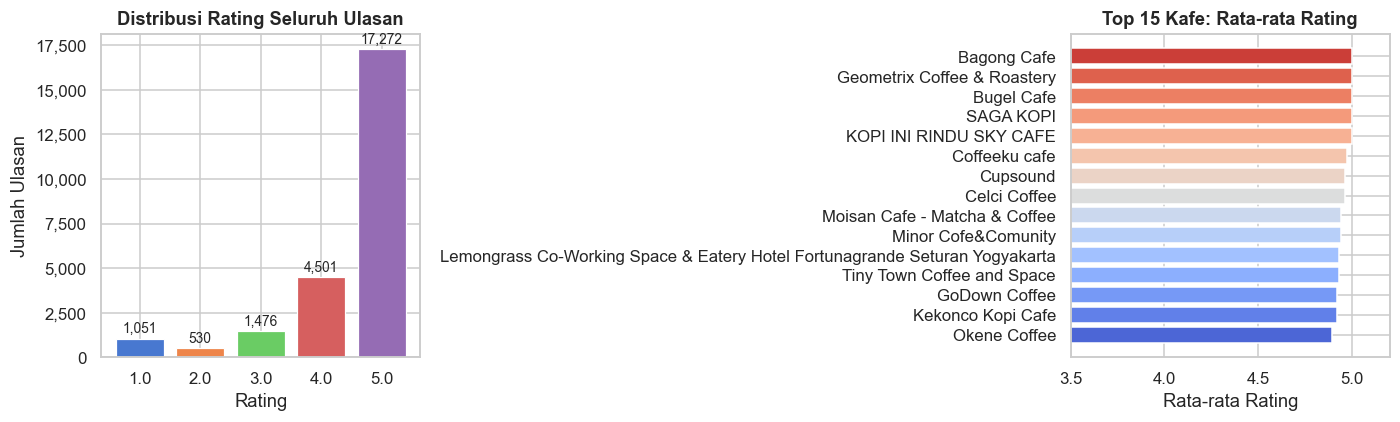

In [25]:
# Visualisasi 1: Distribusi rating seluruh ulasan
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Plot kiri: distribusi rating ---
rating_counts = df['rating'].value_counts().sort_index()
bars = axes[0].bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    color=sns.color_palette('muted', 5),
    edgecolor='white', linewidth=0.8
)
# Tambahkan label nilai di atas tiap bar
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=9
    )
axes[0].set_title('Distribusi Rating Seluruh Ulasan', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- Plot kanan: top 15 kafe berdasarkan rata-rata rating ---
top15 = stats_kafe.sort_values('rata_rating', ascending=False).head(15)
axes[1].barh(
    top15['nama_kafe'],
    top15['rata_rating'],
    color=sns.color_palette('coolwarm_r', 15)
)
axes[1].set_xlim(3.5, 5.2)
axes[1].set_title('Top 15 Kafe: Rata-rata Rating', fontweight='bold')
axes[1].set_xlabel('Rata-rata Rating')
axes[1].invert_yaxis()  # Kafe rating tertinggi di atas

plt.tight_layout()
plt.savefig('./eda_rating.png', bbox_inches='tight')
plt.show()

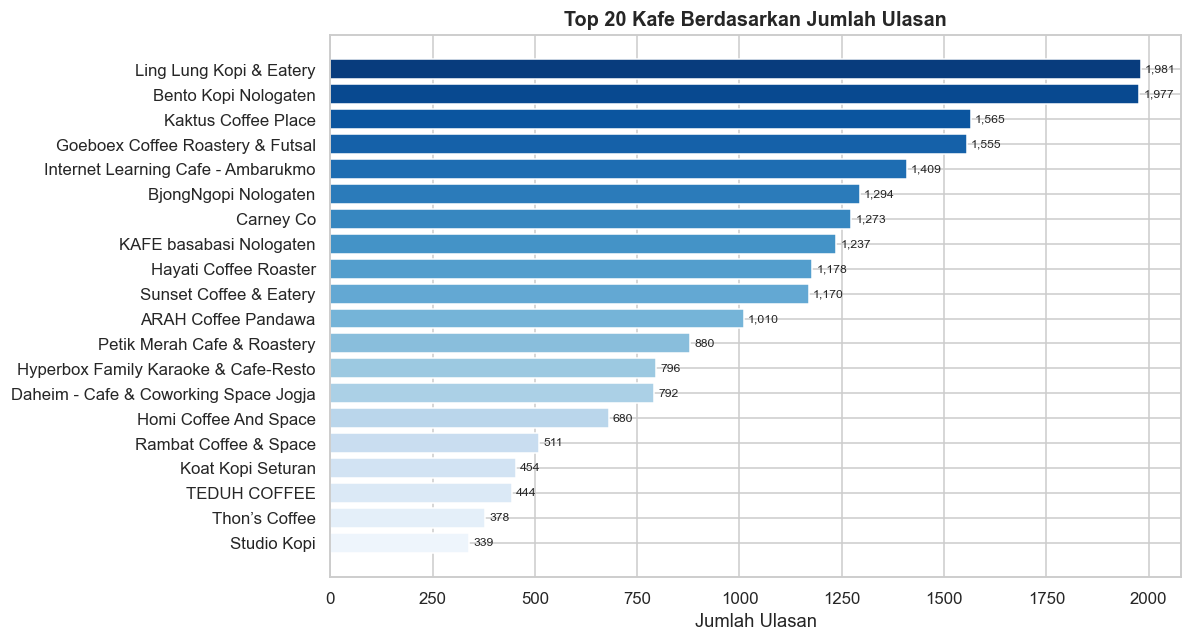

In [26]:
# Visualisasi 2: Top 20 kafe berdasarkan jumlah ulasan
fig, ax = plt.subplots(figsize=(11, 6))

top20 = stats_kafe.head(20)   # Sudah diurutkan descending di atas
palette = sns.color_palette('Blues_r', 20)

bars = ax.barh(top20['nama_kafe'], top20['jumlah_ulasan'], color=palette)
for bar in bars:
    ax.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width()):,}',
        va='center', fontsize=8
    )

ax.set_title('Top 20 Kafe Berdasarkan Jumlah Ulasan', fontweight='bold', fontsize=13)
ax.set_xlabel('Jumlah Ulasan')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('./eda_ulasan.png', bbox_inches='tight')
plt.show()

---
## 5. Membangun Item Profile dengan TF-IDF

### Konsep
Setiap **kafe** direpresentasikan sebagai satu **dokumen** yang merupakan gabungan (agregasi) seluruh ulasan pengunjungnya. Representasi ini kemudian diubah menjadi **vektor TF-IDF**.

**TF-IDF** (Term Frequency - Inverse Document Frequency):
$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\frac{N}{df(t)}$$

- **TF**: Frekuensi kemunculan kata $t$ dalam dokumen $d$
- **IDF**: Seberapa langka kata $t$ di seluruh corpus
- Kata yang sering muncul di satu kafe tapi jarang di kafe lain mendapat bobot tinggi

### Stopwords Bahasa Indonesia
Kata-kata umum (stopwords) seperti "yang", "dan", "di", "ini" dihapus karena tidak membawa informasi pembeda antar kafe.

In [27]:
# Pilih bahasa (misal: indonesia atau english)
stop_words = set(stopwords.words('indonesian'))

# Daftar stopwords Bahasa Indonesia (subset kata paling umum)
# Ini penting agar TF-IDF tidak didominasi kata-kata yang tidak bermakna
STOPWORDS_ID = [
    'yang', 'dan', 'di', 'ini', 'itu', 'dengan', 'untuk', 'ke', 'dari', 'pada',
    'adalah', 'ada', 'juga', 'saya', 'kami', 'kita', 'dia', 'mereka', 'anda',
    'tidak', 'bisa', 'sudah', 'akan', 'atau', 'tapi', 'karena', 'jadi', 'kalau',
    'saat', 'lagi', 'nya', 'buat', 'mau', 'sangat', 'banget', 'sekali', 'pun',
    'aja', 'sih', 'ya', 'yg', 'dgn', 'utk', 'dr', 'si', 'bisa', 'belum',
    'masih', 'lebih', 'paling', 'cuma', 'hanya', 'juga', 'sudah', 'sudh',
    'kalo', 'karna', 'dah', 'udah', 'ga', 'gak', 'tak', 'nggak', 'ngga',
    'tp', 'tapi', 'wkwk', 'haha', 'wkwkwk', 'lol', 'deh', 'dong', 'nih',
    'lah', 'kah', 'kan', 'pun', 'nya', 'mu', 'ku', 'ku', 'lho', 'lo',
    'kopi', 'cafe', 'kafe', 'coffee', 'tempat', 'minum', 'makan', 'pesan',
    'datang', 'kesini', 'sini', 'sana', 'disini', 'disana', 'ke', 'dari',
]

# Ubah baris terakhir menjadi ini:
STOPWORDS_ID = STOPWORDS_ID + list(stop_words)

# Agar tidak ada kata duplikat (opsional tapi disarankan):
STOPWORDS_ID = list(set(STOPWORDS_ID))

print(f'Jumlah stopwords: {len(STOPWORDS_ID)}')

Jumlah stopwords: 797


In [28]:
# LANGKAH KUNCI: Agregasi ulasan per kafe menjadi satu dokumen
# Semua teks ulasan dari pengunjung satu kafe digabung menjadi satu string panjang
# Ini membentuk 'profil konten' tiap kafe
dokumen_kafe = (
    df.groupby('nama_kafe')['teks_bersih']
    .apply(lambda ulasan: ' '.join(ulasan))   # Gabungkan semua ulasan dengan spasi
    .reset_index()
)
dokumen_kafe.columns = ['nama_kafe', 'dokumen_gabungan']

# Gabungkan juga info rata-rata rating ke dalam DataFrame kafe
dokumen_kafe = dokumen_kafe.merge(stats_kafe, on='nama_kafe', how='left')

# Reset index agar bisa digunakan sebagai ID item
dokumen_kafe = dokumen_kafe.reset_index(drop=True)

print(f'Jumlah kafe (item) dalam korpus: {len(dokumen_kafe)}')
print('\nContoh profil kafe pertama (200 karakter pertama):')
print(dokumen_kafe['dokumen_gabungan'].iloc[0][:200])

Jumlah kafe (item) dalam korpus: 83

Contoh profil kafe pertama (200 karakter pertama):
cafenya nyamaan banget buat nugas wifi kenceng banyak colokan gak berisikk kopinya enak banyak varian makanan atau buat cemal cemil baristanya juga ramah recommend banget buat yang nyari coffee shop d


In [29]:
# Inisialisasi TF-IDF Vectorizer dengan parameter yang telah dikonfigurasi
tfidf_vectorizer = TfidfVectorizer(
    stop_words=STOPWORDS_ID,     # Daftar stopwords Bahasa Indonesia
    ngram_range=(1, 2),          # Gunakan unigram DAN bigram (misal: 'enak', 'sangat enak')
    min_df=2,                    # Abaikan term yang muncul di kurang dari 2 kafe
    max_df=0.85,                 # Abaikan term yang muncul di lebih dari 85% kafe (terlalu umum)
    sublinear_tf=True,           # Terapkan log normalisasi pada TF (mengurangi dominasi term sangat sering)
    max_features=5000            # Batasi ke 5000 fitur teratas untuk efisiensi
)

# Fit TF-IDF pada dokumen gabungan tiap kafe, lalu transform menjadi matriks sparse
# Hasilnya: matriks berukuran (jumlah_kafe x jumlah_fitur)
tfidf_matrix = tfidf_vectorizer.fit_transform(dokumen_kafe['dokumen_gabungan'])

print(f'Dimensi TF-IDF matrix : {tfidf_matrix.shape}')
print(f'  - Baris = Jumlah kafe   : {tfidf_matrix.shape[0]}')
print(f'  - Kolom = Jumlah fitur  : {tfidf_matrix.shape[1]}')
print(f'\nContoh 15 fitur (kata/frasa) pertama:')
print(tfidf_vectorizer.get_feature_names_out()[:15].tolist())

Dimensi TF-IDF matrix : (83, 5000)
  - Baris = Jumlah kafe   : 83
  - Kolom = Jumlah fitur  : 5000

Contoh 15 fitur (kata/frasa) pertama:
['abis', 'able', 'abu', 'ac', 'ac ac', 'ac adem', 'ac area', 'ac cocok', 'ac dingin', 'ac lantai', 'ac non', 'ac nyala', 'ac nyaman', 'ac outdoor', 'ac panas']


In [30]:
dokumen_kafe

,nama_kafe,dokumen_gabungan,jumlah_ulasan,rata_rating
0,110 Degree Cafe,cafenya nyamaan banget buat nugas wifi kenceng banyak colokan gak berisikk k...,133,4.85
1,AHA! Cafe,nyaman ada meja billiard nya enak buat nongkrong tempat sahur saat staycatio...,14,4.79
2,ARAH Coffee Pandawa,arah coffee pandawa memiliki lokasi yang sangat strategis di jalan kaliurang...,1010,4.47
3,Alembana Coffee & Community,coba kesini unt belajar kelompok tempatnya cukup luas dan bersih unt ketenan...,284,4.57
4,BAKUDAPA Cafe,tempat ny enak cocok buat nongkrong sma temen makanan dan minuman nya juga m...,13,4.46
...,...,...,...,...
78,Thon’s Coffee,short review mulai dari masuk ya parkir luas bagian motor ada atapnya gaada ...,378,4.29
79,Tiny Town Coffee and Space,coffe shop buat anak skena sihh karena karyawannya jg pada skena tempatnya c...,14,4.93
80,Volare Coffee,best matcha in town versi saya the real matcha yg enggak sekedar susu dicamp...,184,4.85
81,Warung Kopi & Angkringan PASEDULURAN by Veekyu,cafe yg br opening senin okt ini cocok buat ngobrol santai bs dicoba disini ...,14,4.86


In [31]:
# Fungsi untuk menampilkan kata/frasa dengan bobot TF-IDF tertinggi untuk suatu kafe
def top_tfidf_terms(nama_kafe: str, n: int = 10) -> pd.DataFrame:
    """Mengembalikan n term TF-IDF tertinggi untuk kafe yang diminta."""
    # Cari index baris kafe dalam dokumen_kafe
    idx = dokumen_kafe[dokumen_kafe['nama_kafe'] == nama_kafe].index
    if len(idx) == 0:
        return pd.DataFrame({'Pesan': [f'Kafe "{nama_kafe}" tidak ditemukan.']})
    idx = idx[0]
    
    # Ambil vektor TF-IDF kafe tersebut dan ubah ke dense array
    vektor = tfidf_matrix[idx].toarray().flatten()
    
    # Ambil nama semua fitur (kata/frasa)
    fitur = tfidf_vectorizer.get_feature_names_out()
    
    # Urutkan berdasarkan bobot TF-IDF tertinggi
    top_idx = vektor.argsort()[::-1][:n]
    return pd.DataFrame({
        'Term': fitur[top_idx],
        'TF-IDF Score': vektor[top_idx].round(4)
    })

# Tampilkan top terms untuk dua kafe berbeda sebagai contoh
print('=== Top TF-IDF Terms: GoDown Coffee ===')
print(top_tfidf_terms('GoDown Coffee', n=10).to_string(index=False))

print('\n=== Top TF-IDF Terms: Jaga tempo koffie ===')
print(top_tfidf_terms('Jaga tempo koffie', n=10).to_string(index=False))

=== Top TF-IDF Terms: GoDown Coffee ===
            Term  TF-IDF Score
 enak baristanya        0.1554
      tempatnyaa        0.1382
      kampus ugm        0.1286
            seru        0.1241
      minumannya        0.1207
             fix        0.1193
       persiapan        0.1193
baristanya ramah        0.1190
           wenak        0.1155
  lumayan tenang        0.1155

=== Top TF-IDF Terms: Jaga tempo koffie ===
            Term  TF-IDF Score
           steak        0.1337
        teriyaki        0.1209
        steaknya        0.1154
          bukber        0.1146
           paket        0.1053
makanannya enakk        0.1042
       mba ramah        0.1036
             bnr        0.1036
         chicken        0.1014
            jaga        0.0892


---
## 6. Menghitung Cosine Similarity

### Konsep
**Cosine Similarity** mengukur kemiripan arah dua vektor dalam ruang berdimensi tinggi:

$$\text{sim}(A, B) = \frac{A \cdot B}{\|A\| \times \|B\|}$$

- Nilai **1** = identik (arah vektor sama persis)
- Nilai **0** = tidak berkaitan (tegak lurus)
- Nilai **-1** = berlawanan (tidak mungkin pada TF-IDF karena semua nilai >= 0)

Keunggulan cosine similarity adalah **tidak terpengaruh panjang dokumen** - kafe dengan 1000 ulasan tidak otomatis lebih mirip daripada kafe dengan 50 ulasan.

In [32]:
# Hitung matriks cosine similarity antar semua pasang kafe
# Hasilnya: matriks simetris berukuran (n_kafe x n_kafe)
# sim_matrix[i][j] = kemiripan antara kafe i dan kafe j
sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Buat DataFrame dari matriks similarity untuk kemudahan akses
sim_df = pd.DataFrame(
    sim_matrix,
    index=dokumen_kafe['nama_kafe'],     # Nama kafe sebagai indeks baris
    columns=dokumen_kafe['nama_kafe']    # Nama kafe sebagai indeks kolom
)

print(f'Ukuran similarity matrix: {sim_matrix.shape}')
print(f'\nContoh nilai similarity (5x5 pertama):')
sim_df.iloc[:5, :5].round(3)

Ukuran similarity matrix: (83, 83)

Contoh nilai similarity (5x5 pertama):


nama_kafe,110 Degree Cafe,AHA! Cafe,ARAH Coffee Pandawa,Alembana Coffee & Community,BAKUDAPA Cafe
nama_kafe,,,,,
110 Degree Cafe,1.000,0.139,0.375,0.302,0.079
AHA! Cafe,0.139,1.000,0.133,0.150,0.029
ARAH Coffee Pandawa,0.375,0.133,1.000,0.404,0.069
Alembana Coffee & Community,0.302,0.150,0.404,1.000,0.081
BAKUDAPA Cafe,0.079,0.029,0.069,0.081,1.000


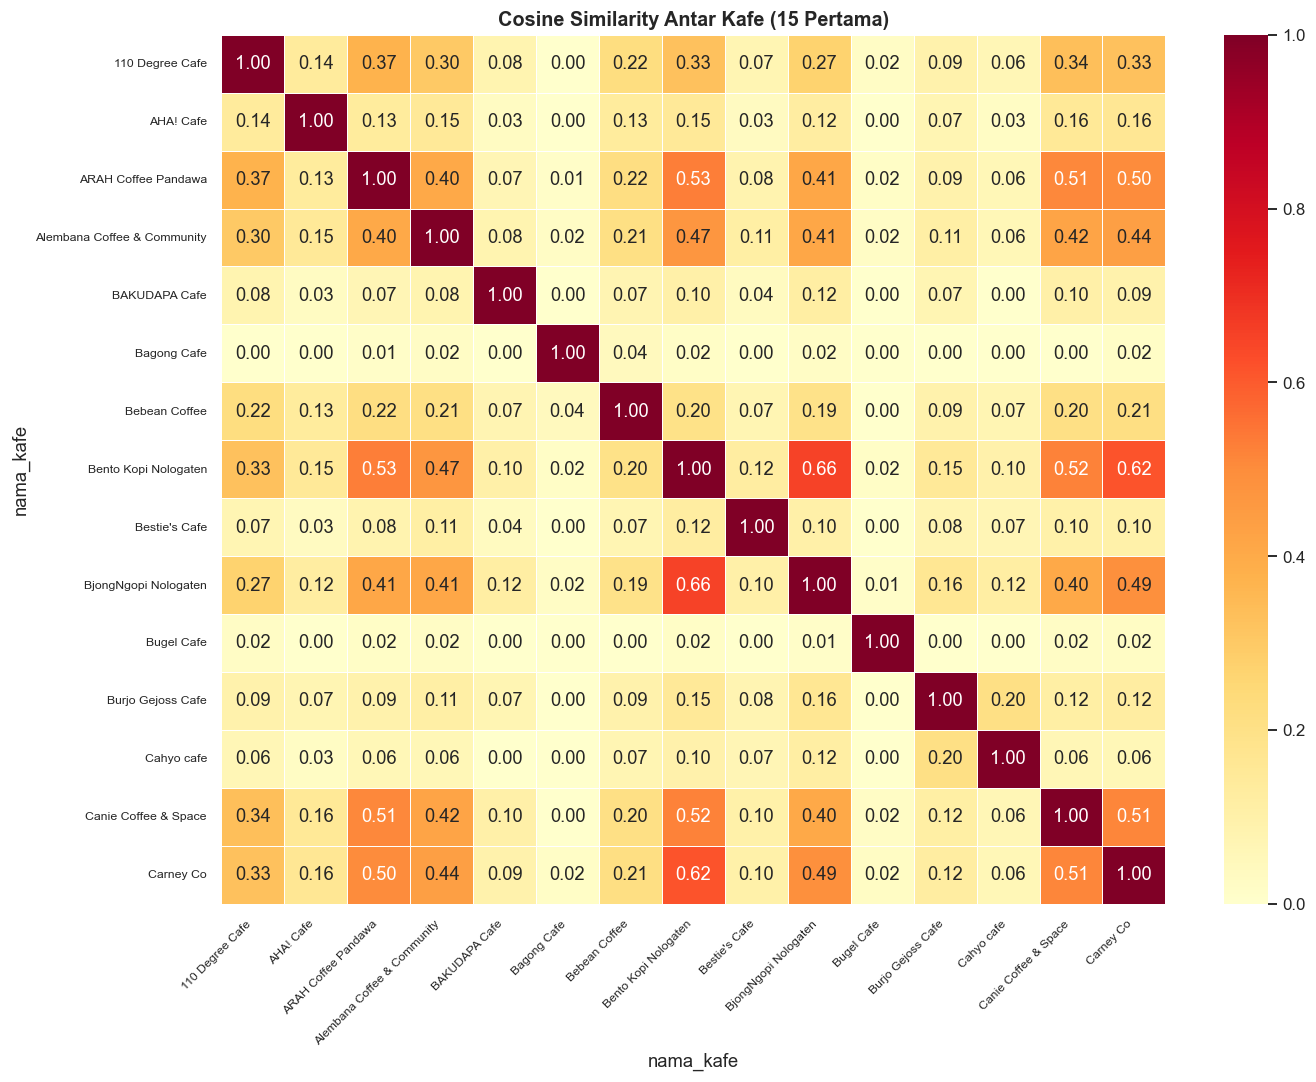

In [33]:
# Visualisasi heatmap cosine similarity untuk 15 kafe pertama
fig, ax = plt.subplots(figsize=(13, 10))

# Gunakan 15 kafe pertama agar heatmap masih terbaca
subset = sim_df.iloc[:15, :15]

sns.heatmap(
    subset,
    annot=True,                  # Tampilkan nilai di setiap sel
    fmt='.2f',                   # Format 2 desimal
    cmap='YlOrRd',               # Colormap kuning-oranye-merah
    linewidths=0.5,              # Garis pemisah antar sel
    ax=ax,
    vmin=0, vmax=1               # Range nilai similarity
)

ax.set_title('Cosine Similarity Antar Kafe (15 Pertama)', fontweight='bold', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('./heatmap_similarity.png', bbox_inches='tight')
plt.show()

---
## 7. Implementasi Content-Based Filtering

### Dua Mode Rekomendasi

**Mode 1 - Item-to-Item:** Diberikan satu kafe, rekomendasikan kafe yang paling mirip secara konten ulasan.

**Mode 2 - User Profile:** Diberikan daftar kafe yang pernah dikunjungi user (dengan rating), bangun user profile sebagai rata-rata tertimbang vektor TF-IDF, lalu rekomendasikan kafe terdekat yang belum dikunjungi.

In [34]:
class ContentBasedFilteringKafe:
    def __init__(self, tfidf_matrix, sim_matrix, dokumen_kafe, tfidf_vectorizer=None):
        self.tfidf_matrix = tfidf_matrix      
        self.sim_matrix   = sim_matrix        
        self.df_kafe      = dokumen_kafe.copy().reset_index(drop=True)
        self.vectorizer   = tfidf_vectorizer  # Disimpan untuk mengambil nama kata/fitur
        
        # Buat mapping nama kafe -> index baris
        self.nama_ke_idx = pd.Series(
            self.df_kafe.index,
            index=self.df_kafe['nama_kafe']
        )
        
        # Hitung Nilai IMDb Global secara otomatis saat inisialisasi
        self.C = self.df_kafe['rata_rating'].mean()
        self.m = 5  # Batas minimal ulasan
        self._hitung_skor_kualitas_global()

    def _hitung_skor_kualitas_global(self):
        """Menghitung nilai rating berbobot IMDb untuk penyeimbang kualitas."""
        v = self.df_kafe['jumlah_ulasan']
        R = self.df_kafe['rata_rating']
        skor_kualitas = (v / (v + self.m) * R) + (self.m / (v + self.m) * self.C)
        self.df_kafe['skor_kualitas_norm'] = skor_kualitas / 5.0

    def _get_top_keywords(self, row_idx, top_k=3):
        """Mengekstrak kata kunci dengan bobot TF-IDF tertinggi untuk kafe tertentu."""
        if self.vectorizer is None:
            return "Vectorizer tidak dilampirkan"
        
        # Ambil vektor TF-IDF untuk baris kafe ini
        row_vector = self.tfidf_matrix[row_idx].toarray().flatten()
        # Ambil index kata dari bobot tertinggi
        top_word_indices = np.argsort(row_vector)[::-1][:top_k]
        # Map indeks ke kata asli
        feature_names = self.vectorizer.get_feature_names_out()
        top_words = [feature_names[i] for i in top_word_indices if row_vector[i] > 0]
        
        return ", ".join(top_words) if top_words else "Tidak ada ulasan dominan"

    # ------------------------------------------------------------------ #
    # MODE 1: ITEM-TO-ITEM RECOMMENDATION (WITH CONTENT COMPARISON)       #
    # ------------------------------------------------------------------ #
    def rekomendasikan_per_item(self, nama_kafe: str, top_n: int = 5, alpha: float = 0.7) -> pd.DataFrame:
        if nama_kafe not in self.nama_ke_idx:
            raise ValueError(f'Kafe "{nama_kafe}" tidak ditemukan. Cek ejaan.')
        
        idx = self.nama_ke_idx[nama_kafe]
        
        # Ambil kata kunci utama untuk kafe acuan
        kata_kunci_acuan = self._get_top_keywords(idx, top_k=4)
        print(f"=== Kafe Acuan: {nama_kafe} ===")
        print(f"Karakteristik Utama Ulasan: [{kata_kunci_acuan}]\n")
        
        # Hitung skor hibrida (Teks + Rating IMDb)
        sim_scores = self.sim_matrix[idx]
        kualitas_scores = self.df_kafe['skor_kualitas_norm'].values
        
        beta = 1.0 - alpha
        final_scores = (alpha * sim_scores) + (beta * kualitas_scores)
        
        # Bangun DataFrame untuk pengurutan
        df_skor = pd.DataFrame({
            'idx': range(len(final_scores)),
            'sim_score': sim_scores,
            'final_score': final_scores
        })
        
        # Urutkan dan lewati index kafe acuan itu sendiri
        df_skor = df_skor[df_skor['idx'] != idx].sort_values(by='final_score', ascending=False)
        top_skor = df_skor.head(top_n)
        
        # Susun output dataframe pembanding
        nama_kafe_list = [self.df_kafe.loc[i, 'nama_kafe'] for i in top_skor['idx']]
        sim_list = top_skor['sim_score'].round(4).tolist()
        rating_list = [self.df_kafe.loc[i, 'rata_rating'] for i in top_skor['idx']]
        ulasan_list = [self.df_kafe.loc[i, 'jumlah_ulasan'] for i in top_skor['idx']]
        
        # Ekstrak kata kunci dari masing-masing rekomendasi
        keywords_list = [self._get_top_keywords(i, top_k=3) for i in top_skor['idx']]
        
        hasil = pd.DataFrame({
            'Nama Kafe': nama_kafe_list,
            'Teks Similarity': sim_list,
            'Rata Rating': rating_list,
            'Total Ulasan': ulasan_list,
            'Top Content Keywords': keywords_list
        })
        return hasil.reset_index(drop=True)

    # ------------------------------------------------------------------ #
    # MODE 2: USER PROFILE RECOMMENDATION (WITH CONTENT COMPARISON)       #
    # ------------------------------------------------------------------ #
    def rekomendasikan_per_user(self, kafe_dikunjungi: list, rating_user: list = None, top_n: int = 5) -> pd.DataFrame:
        for nama in kafe_dikunjungi:
            if nama not in self.nama_ke_idx:
                raise ValueError(f'Kafe "{nama}" tidak ditemukan.')
        
        idx_dikunjungi = [self.nama_ke_idx[n] for n in kafe_dikunjungi]
        
        if rating_user is None:
            bobot = np.ones(len(idx_dikunjungi))
        else:
            bobot = np.array(rating_user, dtype=float)
        bobot = bobot / bobot.sum()
        
        # Buat profil preferensi user (Vektor User)
        vektor_user = np.average(self.tfidf_matrix[idx_dikunjungi].toarray(), axis=0, weights=bobot)
        
        # Cetak kata kunci yang disukai user berdasarkan bobot kunjungannya
        feature_names = self.vectorizer.get_feature_names_out()
        top_user_idx = np.argsort(vektor_user)[::-1][:4]
        user_keywords = [feature_names[i] for i in top_user_idx if vektor_user[i] > 0]
        print(f"=== Profil Preferensi Pengguna ===")
        print(f"Mencari kafe dengan konten: [{', '.join(user_keywords)}]\n")
        
        # Hitung similarity vektor user dengan semua kafe
        skor_user = cosine_similarity(vektor_user.reshape(1, -1), self.tfidf_matrix).flatten()
        skor_user[idx_dikunjungi] = -1.0 # Blokir kafe lama
        
        top_idx = np.argsort(skor_user)[::-1][:top_n]
        
        keywords_list = [self._get_top_keywords(i, top_k=3) for i in top_idx]
        
        hasil = pd.DataFrame({
            'Nama Kafe': self.df_kafe.loc[top_idx, 'nama_kafe'].values,
            'User Match Score': skor_user[top_idx].round(4),
            'Rata Rating': self.df_kafe.loc[top_idx, 'rata_rating'].values,
            'Total Ulasan': self.df_kafe.loc[top_idx, 'jumlah_ulasan'].values,
            'Top Content Keywords': keywords_list
        })
        return hasil.reset_index(drop=True)

In [35]:
import pickle

# Siapkan data dalam satu dictionary agar rapi
model_data = {
    'tfidf_matrix': tfidf_matrix,
    'sim_matrix': sim_matrix,
    'df_kafe': dokumen_kafe
}

# Simpan ke file .pkl
with open('model_kafe.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Model berhasil disimpan!")

Model berhasil disimpan!


---
## 8. Pengujian Mode 1: Item-to-Item Recommendation

In [24]:
# Inisialisasi Class Baru dengan menyertakan object vectorizer TF-IDF kamu
sistem_cbf = ContentBasedFilteringKafe(
    tfidf_matrix=tfidf_matrix,
    sim_matrix=sim_matrix,  # Matriks Cosine Similarity
    dokumen_kafe=dokumen_kafe,         # Dataframe kafe hasil agregasi
    tfidf_vectorizer=tfidf_vectorizer         # Object TF-IDF Vectorizer dari scikit-learn
)

# 1. TEST REKOMENDASI ITEM-TO-ITEM (Alpha 0.7 = 70% Teks, 30% Rating)
# Uji dengan kafe acuan kedua
kafe_acuan = '110 Degree Cafe'

rekomendasi_item = sistem_cbf.rekomendasikan_per_item(
    nama_kafe=kafe_acuan,
    top_n=7
)

print(f'=== Rekomendasi Kafe Serupa dengan "{kafe_acuan}" ===')
print(rekomendasi_item.to_string(index=False))

=== Kafe Acuan: 110 Degree Cafe ===
Karakteristik Utama Ulasan: [hai kak, hai, pistachio, kasih reviewnya]

=== Rekomendasi Kafe Serupa dengan "110 Degree Cafe" ===
                            Nama Kafe  Teks Similarity  Rata Rating  Total Ulasan                                 Top Content Keywords
Daheim - Cafe & Coworking Space Jogja           0.3510     4.795455           792                                  ktm, pandega, eropa
                  ARAH Coffee Pandawa           0.3746     4.470297          1010              ulasan positif, motivasi, mengapresiasi
                Rambat Coffee & Space           0.3344     4.745597           511                           burger, outdoor semi, live
           DKonkrit Coffee and Eatery           0.3291     4.807309           301              rooftop, terimakasih berkunjung, lantai
                  Kaktus Coffee Place           0.3396     4.660703          1565                   salted caramel, ramennya, charcoal
                    Obie 

In [25]:
# Uji dengan kafe acuan kedua
kafe_acuan2 = 'Jaga tempo koffie'

rekomendasi_item2 = sistem_cbf.rekomendasikan_per_item(
    nama_kafe=kafe_acuan2,
    top_n=7
)

print(f'=== Rekomendasi Kafe Serupa dengan "{kafe_acuan2}" ===')
print(rekomendasi_item2.to_string(index=False))

=== Kafe Acuan: Jaga tempo koffie ===
Karakteristik Utama Ulasan: [steak, teriyaki, steaknya, bukber]

=== Rekomendasi Kafe Serupa dengan "Jaga tempo koffie" ===
                            Nama Kafe  Teks Similarity  Rata Rating  Total Ulasan                           Top Content Keywords
Daheim - Cafe & Coworking Space Jogja           0.2691     4.795455           792                            ktm, pandega, eropa
           DKonkrit Coffee and Eatery           0.2509     4.807309           301        rooftop, terimakasih berkunjung, lantai
                          Steak Eseme           0.2453     4.829787            94                      kasih terima, daun, jeruk
                Rambat Coffee & Space           0.2476     4.745597           511                     burger, outdoor semi, live
          Alembana Coffee & Community           0.2534     4.570423           284 terimakasih kak, kak ditunggu, kak terimakasih
                  Kaktus Coffee Place           0.2409     4.660

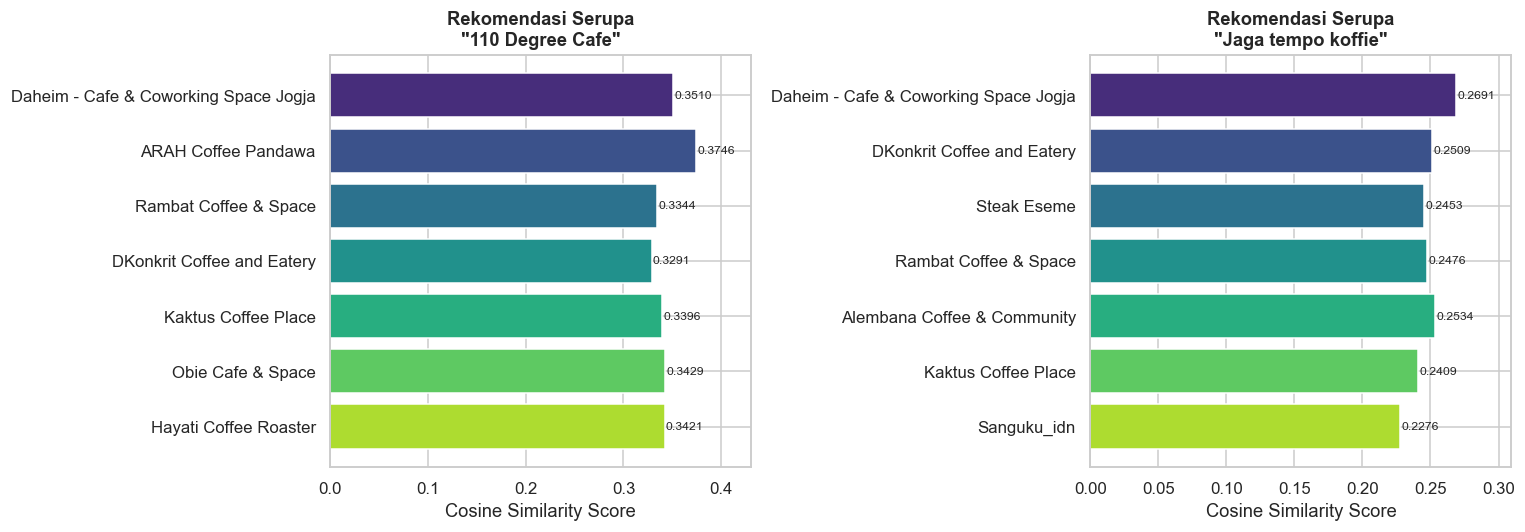

In [27]:
# Visualisasi: Bar chart skor similarity untuk dua kafe acuan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (acuan, df_rek) in zip(axes, [
    (kafe_acuan, rekomendasi_item),
    (kafe_acuan2, rekomendasi_item2)
]):
    palette = sns.color_palette('viridis', len(df_rek))
    bars = ax.barh(df_rek['Nama Kafe'], df_rek['Teks Similarity'], color=palette)
    
    # Tampilkan nilai di ujung bar
    for bar in bars:
        ax.text(
            bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.4f}',
            va='center', fontsize=8
        )
    
    ax.set_title(f'Rekomendasi Serupa\n"{acuan}"', fontweight='bold')
    ax.set_xlabel('Cosine Similarity Score')
    ax.invert_yaxis()              # Tertinggi di atas
    ax.set_xlim(0, df_rek['Teks Similarity'].max() * 1.15)

plt.tight_layout()
plt.savefig('./viz_item_recommendation.png', bbox_inches='tight')
plt.show()

---
## 9. Pengujian Mode 2: User Profile Recommendation

Skenario: Seorang user pernah mengunjungi beberapa kafe dan memberikan rating. Sistem membangun **user profile** sebagai rata-rata tertimbang vektor TF-IDF kafe yang dikunjungi, lalu mencari kafe yang paling sesuai profil tersebut.

In [28]:
# Skenario User A: Pengunjung yang suka kafe dengan nuansa roastery dan kopi specialty
user_a_kafe   = ['GoDown Coffee', 'Geometrix Coffee & Roastery', 'KAVELO | Coffee Lounge']
user_a_rating = [5, 4, 5]     # Rating yang diberikan user untuk masing-masing kafe

rek_user_a = sistem_cbf.rekomendasikan_per_user(
    kafe_dikunjungi=user_a_kafe,
    rating_user=user_a_rating,
    top_n=7
)

print('=== Rekomendasi untuk User A ===')
print(f'Riwayat kunjungan: {user_a_kafe}')
print(f'Rating diberikan : {user_a_rating}')
print()
print(rek_user_a.to_string(index=False))

=== Profil Preferensi Pengguna ===
Mencari kafe dengan konten: [bercengkrama, seru, mantap, menu]

=== Rekomendasi untuk User A ===
Riwayat kunjungan: ['GoDown Coffee', 'Geometrix Coffee & Roastery', 'KAVELO | Coffee Lounge']
Rating diberikan : [5, 4, 5]

                            Nama Kafe  User Match Score  Rata Rating  Total Ulasan                                 Top Content Keywords
                           NAWWA KOPI            0.2823     4.683036           224                                   croffle, uny, ruko
                  Kaktus Coffee Place            0.2793     4.660703          1565                   salted caramel, ramennya, charcoal
                 XYZ Coffee & Collabs            0.2753     4.474359           156                                    ramen, botol, egg
                    Obie Cafe & Space            0.2705     4.615063           239 kedatangan terima, kasih mampir, ditunggu kedatangan
          Petik Merah Cafe & Roastery            0.2681         

In [29]:
# Skenario User B: Pengunjung yang suka coworking space dan cafe untuk kerja
user_b_kafe   = ['Tadeus Coworking & Cafe', 'Daheim - Cafe & Coworking Space Jogja', 'Obie Cafe & Space']
user_b_rating = [4, 5, 4]

rek_user_b = sistem_cbf.rekomendasikan_per_user(
    kafe_dikunjungi=user_b_kafe,
    rating_user=user_b_rating,
    top_n=7
)

print('=== Rekomendasi untuk User B ===')
print(f'Riwayat kunjungan: {user_b_kafe}')
print(f'Rating diberikan : {user_b_rating}')
print()
print(rek_user_b.to_string(index=False))

=== Profil Preferensi Pengguna ===
Mencari kafe dengan konten: [coworking, space, nugas, coworking space]

=== Rekomendasi untuk User B ===
Riwayat kunjungan: ['Tadeus Coworking & Cafe', 'Daheim - Cafe & Coworking Space Jogja', 'Obie Cafe & Space']
Rating diberikan : [4, 5, 4]

                  Nama Kafe  User Match Score  Rata Rating  Total Ulasan               Top Content Keywords
        Kaktus Coffee Place            0.6596     4.660703          1565 salted caramel, ramennya, charcoal
      Homi Coffee And Space            0.6540     4.342647           680 homi, and space, tunggu kedatangan
              Thon’s Coffee            0.6168     4.293651           378          seturan, lantai, dilantai
       Canie Coffee & Space            0.6056     4.325658           304               pandega, gyoza, bill
       Bento Kopi Nologaten            0.6012     4.344967          1977             bento, nologaten, live
Petik Merah Cafe & Roastery            0.5966          NaN           880 

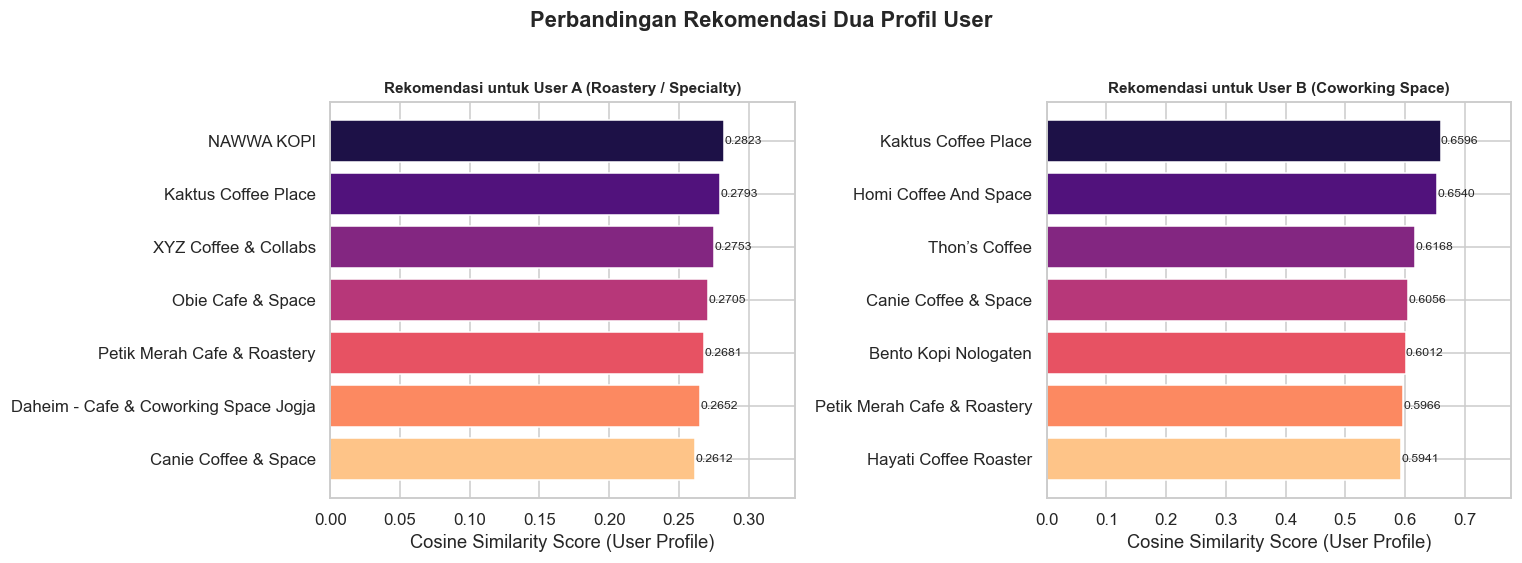

In [31]:
# Visualisasi perbandingan rekomendasi User A vs User B
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, df_rek, kafe_asal) in zip(axes, [
    ('User A (Roastery / Specialty)', rek_user_a, user_a_kafe),
    ('User B (Coworking Space)', rek_user_b, user_b_kafe)
]):
    palette = sns.color_palette('magma', len(df_rek))
    bars = ax.barh(df_rek['Nama Kafe'], df_rek['Similarity Score'], color=palette)
    
    for bar in bars:
        ax.text(
            bar.get_width() + 0.0005,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.4f}',
            va='center', fontsize=8
        )
    
    ax.set_title(f'Rekomendasi untuk {label}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Cosine Similarity Score (User Profile)')
    ax.invert_yaxis()
    ax.set_xlim(0, df_rek['Similarity Score'].max() * 1.18)

plt.suptitle('Perbandingan Rekomendasi Dua Profil User', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./viz_user_recommendation.png', bbox_inches='tight')
plt.show()

---
## 10. Analisis Distribusi Similarity

Memahami sebaran nilai similarity di seluruh pasang kafe untuk menilai kualitas diskriminasi model.

In [33]:
# Ambil semua nilai similarity dari segitiga atas matriks (tanpa diagonal = self-similarity)
# np.triu_indices menghasilkan indeks baris & kolom segitiga atas
n = sim_matrix.shape[0]
rows, cols = np.triu_indices(n, k=1)          # k=1 berarti satu di atas diagonal
semua_skor = sim_matrix[rows, cols]            # Ambil nilai-nilai tersebut

print(f'Jumlah pasang kafe    : {len(semua_skor):,}')
print(f'Rata-rata similarity  : {semua_skor.mean():.4f}')
print(f'Median similarity     : {np.median(semua_skor):.4f}')
print(f'Std deviasi           : {semua_skor.std():.4f}')
print(f'Min similarity        : {semua_skor.min():.4f}')
print(f'Max similarity        : {semua_skor.max():.4f}')

Jumlah pasang kafe    : 3,403
Rata-rata similarity  : 0.1868
Median similarity     : 0.1567
Std deviasi           : 0.1340
Min similarity        : 0.0000
Max similarity        : 0.6850


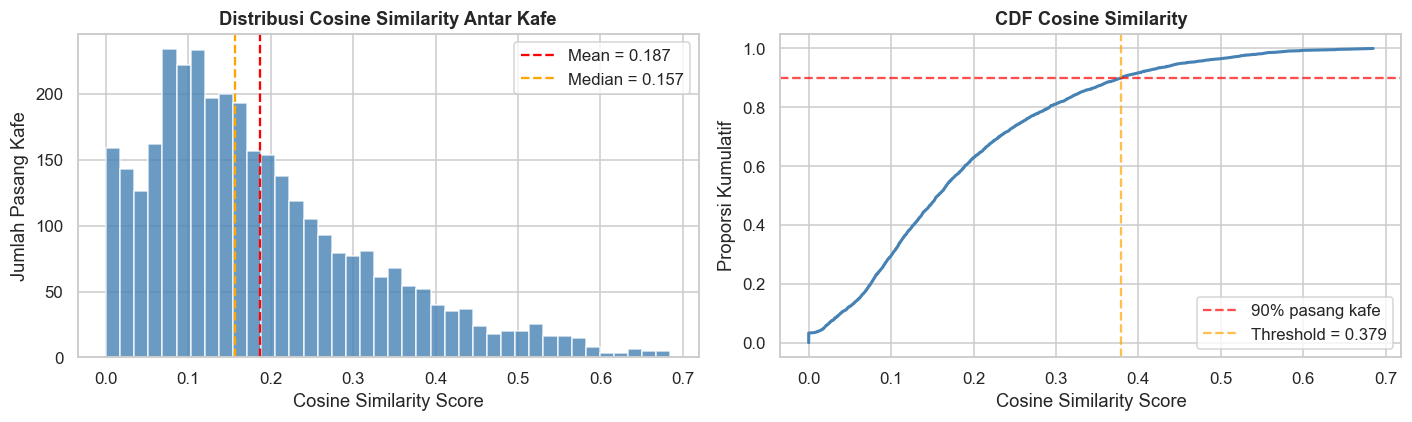

In [34]:
# Visualisasi distribusi similarity antar semua pasang kafe
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Plot kiri: histogram distribusi ---
axes[0].hist(semua_skor, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(semua_skor.mean(), color='red', linestyle='--', label=f'Mean = {semua_skor.mean():.3f}')
axes[0].axvline(np.median(semua_skor), color='orange', linestyle='--', label=f'Median = {np.median(semua_skor):.3f}')
axes[0].set_title('Distribusi Cosine Similarity Antar Kafe', fontweight='bold')
axes[0].set_xlabel('Cosine Similarity Score')
axes[0].set_ylabel('Jumlah Pasang Kafe')
axes[0].legend()

# --- Plot kanan: CDF (Cumulative Distribution Function) ---
skor_sorted = np.sort(semua_skor)                          # Urutkan ascending
cdf = np.arange(1, len(skor_sorted) + 1) / len(skor_sorted)  # Hitung proporsi kumulatif
axes[1].plot(skor_sorted, cdf, color='steelblue', linewidth=2)
axes[1].axhline(0.9, color='red', linestyle='--', alpha=0.7, label='90% pasang kafe')
threshold_90 = np.percentile(semua_skor, 90)
axes[1].axvline(threshold_90, color='orange', linestyle='--', alpha=0.7, label=f'Threshold = {threshold_90:.3f}')
axes[1].set_title('CDF Cosine Similarity', fontweight='bold')
axes[1].set_xlabel('Cosine Similarity Score')
axes[1].set_ylabel('Proporsi Kumulatif')
axes[1].legend()

plt.tight_layout()
plt.savefig('./viz_distribusi_similarity.png', bbox_inches='tight')
plt.show()

---
## 11. Evaluasi: Precision@K

### Konsep Evaluasi CBF
Karena tidak ada ground truth eksplisit (tidak ada data 'kafe mana yang sebenarnya mirip'), evaluasi dilakukan dengan **proxy metric**: dua kafe dianggap **relevan** jika memiliki rata-rata rating yang berdekatan (selisih <= 0.5). Ini mengasumsikan kafe dengan kualitas serupa (tercermin dari rating) kemungkinan memiliki pengalaman yang serupa.

$$\text{Precision@K} = \frac{\text{Jumlah item relevan dalam top-K}}{K}$$

In [35]:
def precision_at_k(nama_kafe: str, k: int = 5, threshold_rating: float = 0.5) -> float:
    """
    Hitung Precision@K untuk satu kafe.
    
    Definisi relevan: kafe yang direkomendasikan memiliki rata-rata rating
    yang selisihnya <= threshold_rating dari kafe acuan.
    
    Parameter:
        nama_kafe        : Nama kafe acuan
        k                : Jumlah rekomendasi yang dievaluasi
        threshold_rating : Toleransi perbedaan rating (default 0.5)
    """
    # Dapatkan rata-rata rating kafe acuan
    rating_acuan = dokumen_kafe.loc[
        dokumen_kafe['nama_kafe'] == nama_kafe, 'rata_rating'
    ].values[0]
    
    # Dapatkan K rekomendasi teratas
    rekom = sistem_cbf.rekomendasikan_per_item(nama_kafe, top_n=k)
    
    # Hitung berapa rekomendasi yang 'relevan' (selisih rating <= threshold)
    relevan = (abs(rekom['Rata-rata Rating'] - rating_acuan) <= threshold_rating).sum()
    
    return relevan / k   # Precision = relevan / total yang direkomendasikan


# Evaluasi Precision@K untuk semua kafe dalam korpus
K_EVALUASI = [3, 5, 7, 10]    # Nilai K yang akan dievaluasi
hasil_evaluasi = {}

for k in K_EVALUASI:
    presisi_list = []
    for nama in dokumen_kafe['nama_kafe']:
        try:
            p = precision_at_k(nama, k=k, threshold_rating=0.5)
            presisi_list.append(p)
        except:
            pass
    
    # Simpan rata-rata Precision@K atas semua kafe
    hasil_evaluasi[f'Precision@{k}'] = np.mean(presisi_list)

print('=== Hasil Evaluasi CBF (Mean Precision@K) ===')
print('Definisi relevan: selisih rata-rata rating <= 0.5')
print()
for metrik, nilai in hasil_evaluasi.items():
    print(f'  {metrik:15s} = {nilai:.4f} ({nilai*100:.1f}%)')

=== Hasil Evaluasi CBF (Mean Precision@K) ===
Definisi relevan: selisih rata-rata rating <= 0.5

  Precision@3     = 0.8554 (85.5%)
  Precision@5     = 0.8096 (81.0%)
  Precision@7     = 0.8038 (80.4%)
  Precision@10    = 0.7904 (79.0%)


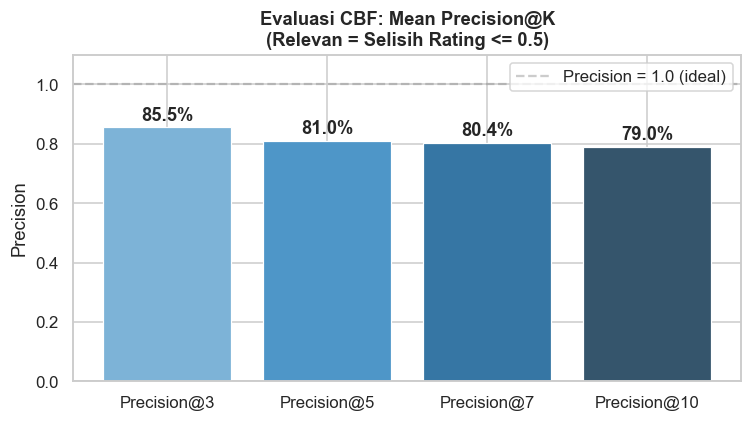

In [36]:
# Visualisasi hasil evaluasi Precision@K
fig, ax = plt.subplots(figsize=(7, 4))

metrik_labels = list(hasil_evaluasi.keys())       # ['Precision@3', 'Precision@5', ...]
nilai_vals = list(hasil_evaluasi.values())         # Nilai presisi

bars = ax.bar(
    metrik_labels, nilai_vals,
    color=sns.color_palette('Blues_d', len(metrik_labels)),
    edgecolor='white', linewidth=0.8
)

# Tambahkan label persentase di atas tiap bar
for bar, val in zip(bars, nilai_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val*100:.1f}%',
        ha='center', va='bottom', fontweight='bold'
    )

ax.set_ylim(0, 1.1)
ax.set_title('Evaluasi CBF: Mean Precision@K\n(Relevan = Selisih Rating <= 0.5)', fontweight='bold')
ax.set_ylabel('Precision')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4, label='Precision = 1.0 (ideal)')
ax.legend()

plt.tight_layout()
plt.savefig('./viz_evaluasi.png', bbox_inches='tight')
plt.show()

---
## 12. Ringkasan

### Apa yang Telah Dibangun

Sistem rekomendasi berbasis **Content-Based Filtering** dengan pipeline:

```
84 file CSV ulasan Google Maps
    → Preprocessing teks (lowercase, remove noise)
    → Agregasi ulasan per kafe → 84 dokumen
    → TF-IDF Vectorization (unigram + bigram, 5000 fitur)
    → Cosine Similarity Matrix (84 x 84)
    → Rekomendasi Item-to-Item / User Profile
```

### Interpretasi Hasil

- **Item-to-Item**: Kafe yang mendapat rekomendasi serupa cenderung berbagi kata kunci ulasan yang sama (misal: 'nugas', 'cozy', 'wifi', 'stopkontak' untuk kafe coworking; 'espresso', 'single origin', 'roastery' untuk kafe specialty).
- **User Profile**: Kafe yang direkomendasikan mencerminkan gabungan preferensi user, dengan bobot lebih tinggi pada kafe yang diberi rating lebih tinggi.

### Keterbatasan dan Arah Pengembangan

| Keterbatasan | Solusi Potensial |
|---|---|
| Stopwords hanya sebagian | Gunakan library PySastrawi (stemming Bahasa Indonesia) |
| TF-IDF tidak menangkap semantik | Ganti dengan sentence embeddings (IndoBERT) |
| Evaluasi menggunakan proxy (rating) | Kumpulkan ground truth eksplisit (user study) |
| Over-specialization | Kombinasikan dengan Collaborative Filtering (Hybrid) |
| Tidak menangkap tren terkini | Tambahkan bobot temporal pada ulasan terbaru |

In [37]:
# Ringkasan statistik akhir sistem
print('=' * 55)
print('  RINGKASAN SISTEM CONTENT-BASED FILTERING KAFE')
print('=' * 55)
print(f'  Total ulasan diproses   : {len(df):>8,}')
print(f'  Jumlah kafe (item)      : {len(dokumen_kafe):>8}')
print(f'  Dimensi TF-IDF          : {tfidf_matrix.shape[0]:>4} x {tfidf_matrix.shape[1]}')
print(f'  Ukuran similarity matrix: {sim_matrix.shape[0]:>4} x {sim_matrix.shape[1]}')
print('-' * 55)
for metrik, nilai in hasil_evaluasi.items():
    print(f'  {metrik:18s} : {nilai:.4f} ({nilai*100:.1f}%)')
print('=' * 55)

  RINGKASAN SISTEM CONTENT-BASED FILTERING KAFE
  Total ulasan diproses   :   25,710
  Jumlah kafe (item)      :       83
  Dimensi TF-IDF          :   83 x 5000
  Ukuran similarity matrix:   83 x 83
-------------------------------------------------------
  Precision@3        : 0.8554 (85.5%)
  Precision@5        : 0.8096 (81.0%)
  Precision@7        : 0.8038 (80.4%)
  Precision@10       : 0.7904 (79.0%)
